# Bayesian Neural Networks

Working with Bayesian neural networks in ProbJax.

In [1]:
%reload_ext autoreload
%autoreload 2

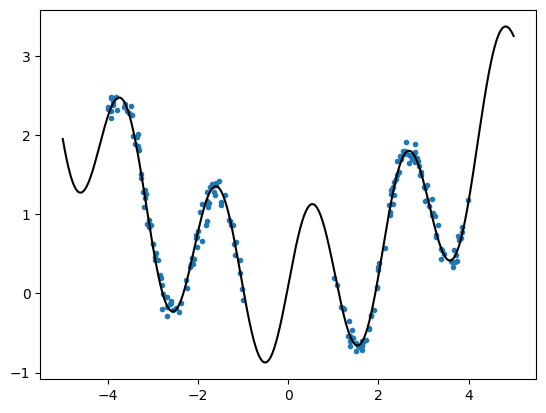

In [13]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from flax import nnx

from probjax.nn import MLP

x_true = np.linspace(-5, 5, 1000)
y_true = 0.1 * x_true**2 + 0.1 + np.sin(3 * x_true)
X = np.concatenate([np.random.uniform(-4, -1, size=100), np.random.uniform(1, 4, size=100)])[..., None]
Y = 0.1 * X**2 + 0.1 + jnp.sin(3 * X) + np.random.normal(0, 0.1, size=X.shape)
plt.plot(X,Y, '.')
plt.plot(x_true, y_true, 'k-')

In [15]:
model = MLP([1,20,20,20,1], rngs=nnx.Rngs(0))
nnx.display(model)

In [16]:
def logdensity_fn(model, sigma: float = 0.1):
    y = model(X)
    # L2 regularization (Gaussian prior) - properly sum squared weights
    l2_reg = jax.tree_util.tree_reduce(lambda acc, y: acc + jnp.sum(y**2), model, 0.0)
    return -0.5*jnp.sum((Y - y)**2/sigma**2) - 0.5*l2_reg


In [17]:
jax.jit(logdensity_fn)(model)

Array(-21156.35, dtype=float32)

In [18]:
import jax

from probjax.inference.mcmc import dynamic_hmc
from probjax.inference.mcmc_runner import MCMC

kernel = dynamic_hmc(logdensity_fn, average_integration_steps=100)

state = kernel.init(model, rng_key=jax.random.PRNGKey(0))
params = kernel.init_params(model)

In [19]:
mcmc = MCMC(kernel, verbose=True)

In [20]:
state, params = kernel.fit_params(jax.random.key(0), state, params, 10_000)
state.logdensity.block_until_ready()

Array(-515.0838, dtype=float32)

In [21]:
samples, state = mcmc.sample(jax.random.PRNGKey(113), state, 500, params, thin=10)
state.logdensity.block_until_ready()

Progress: |██████████████████████████████████████████████████| 100.00% logdensity: -488.88 acceptance_rate: 0.95

Array(-483.58932, dtype=float32)

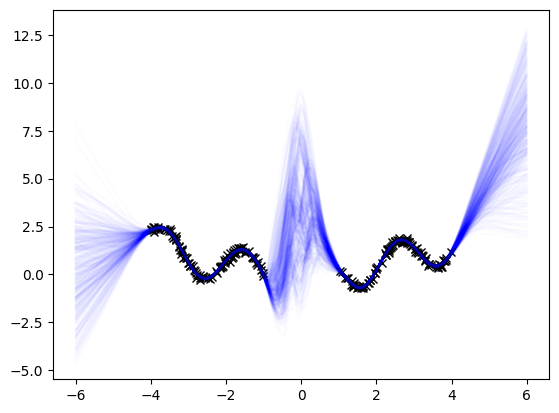

In [24]:
def predict(model, X):
    return model(X)
X_test = np.linspace(-6, 6, 1000)[:, None]
preds = jax.vmap(predict, in_axes=(0, None))(samples, X_test)
plt.plot(X, Y, 'kx')
_ = plt.plot(X_test, preds[...,0].T, 'b', alpha=0.01)